In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Automobile_data.csv')

In [24]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheel-base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [8]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [11]:
for column in df.columns:
  if '?' in df[column].unique():
    print(column)

normalized-losses
num-of-doors
bore
stroke
horsepower
peak-rpm
price


In [18]:
df['normalized-losses'] = df['normalized-losses'].replace('?', np.nan)
df['num-of-doors'] = df['num-of-doors'].replace('?', np.nan)
df['bore'] = df['bore'].replace('?', np.nan)
df['stroke'] = df['stroke'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['peak-rpm'] = df['peak-rpm'].replace('?', np.nan)
df['price'] = df['price'].replace('?', np.nan)

In [20]:
df.isnull().sum()/len(df)*100

,0
symboling,0.00000
normalized-losses,20.00000
make,0.00000
fuel-type,0.00000
aspiration,0.00000
num-of-doors,0.97561
body-style,0.00000
drive-wheels,0.00000
engine-location,0.00000
wheel-base,0.00000


In [25]:
df.dropna(inplace=True)

In [26]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [31]:
liste_object = []
for column in df.columns:
  if df[column].dtype == 'object':
    liste_object.append(column)
    print(column)

normalized-losses
make
fuel-type
aspiration
num-of-doors
body-style
drive-wheels
engine-location
engine-type
num-of-cylinders
fuel-system
bore
stroke
horsepower
peak-rpm
price


In [33]:
objet = df[liste_object]

In [34]:
objet

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,bore,stroke,horsepower,peak-rpm,price
3,164,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.19,3.4,102,5500,13950
4,164,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi,3.19,3.4,115,5500,17450
6,158,audi,gas,std,four,sedan,fwd,front,ohc,five,mpfi,3.19,3.4,110,5500,17710
8,158,audi,gas,turbo,four,sedan,fwd,front,ohc,five,mpfi,3.13,3.4,140,5500,23875
10,192,bmw,gas,std,two,sedan,rwd,front,ohc,four,mpfi,3.5,2.8,101,5800,16430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,95,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi,3.78,3.15,114,5400,16845
201,95,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi,3.78,3.15,160,5300,19045
202,95,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi,3.58,2.87,134,5500,21485
203,95,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi,3.01,3.4,106,4800,22470


In [35]:
objet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 3 to 204
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   normalized-losses  159 non-null    object
 1   make               159 non-null    object
 2   fuel-type          159 non-null    object
 3   aspiration         159 non-null    object
 4   num-of-doors       159 non-null    object
 5   body-style         159 non-null    object
 6   drive-wheels       159 non-null    object
 7   engine-location    159 non-null    object
 8   engine-type        159 non-null    object
 9   num-of-cylinders   159 non-null    object
 10  fuel-system        159 non-null    object
 11  bore               159 non-null    object
 12  stroke             159 non-null    object
 13  horsepower         159 non-null    object
 14  peak-rpm           159 non-null    object
 15  price              159 non-null    object
dtypes: object(16)
memory usage: 21.1+ KB


In [36]:
entier = ['normalized-losses', 'horsepower', 'peak-rpm']

In [37]:
decimal = ['bore', 'stroke', 'price']

In [39]:
df[entier] = df[entier].astype(int)

In [40]:
df[decimal] = df[decimal].astype(float)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 3 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          159 non-null    int64  
 1   normalized-losses  159 non-null    int64  
 2   make               159 non-null    object 
 3   fuel-type          159 non-null    object 
 4   aspiration         159 non-null    object 
 5   num-of-doors       159 non-null    object 
 6   body-style         159 non-null    object 
 7   drive-wheels       159 non-null    object 
 8   engine-location    159 non-null    object 
 9   wheel-base         159 non-null    float64
 10  length             159 non-null    float64
 11  width              159 non-null    float64
 12  height             159 non-null    float64
 13  curb-weight        159 non-null    int64  
 14  engine-type        159 non-null    object 
 15  num-of-cylinders   159 non-null    object 
 16  engine-size        159 non-null

In [44]:
df.corr(numeric_only=True)['price'].sort_values()

,price
highway-mpg,-0.720090
city-mpg,-0.692273
peak-rpm,-0.171916
symboling,-0.162794
stroke,0.160664
normalized-losses,0.202761
compression-ratio,0.209361
height,0.244836
bore,0.533890
wheel-base,0.734419


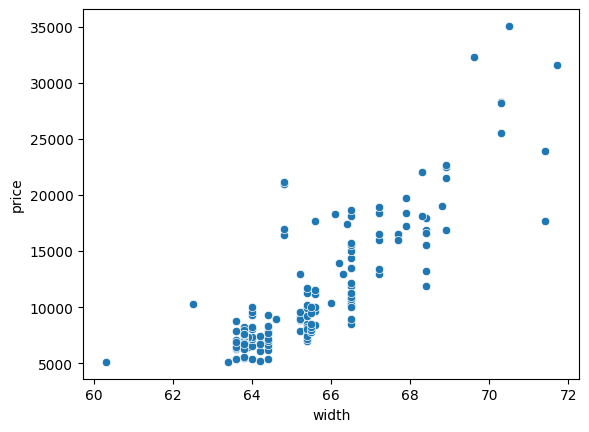

In [46]:
sns.scatterplot(data=df, x='width', y='price')
plt.show()

In [50]:
df[(df['price']<5500) & (df['width']<65)]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
18,2,121,chevrolet,gas,std,two,hatchback,fwd,front,88.4,...,61,2bbl,2.91,3.03,9.5,48,5100,47,53,5151.0
32,1,101,honda,gas,std,two,hatchback,fwd,front,93.7,...,79,1bbl,2.91,3.07,10.1,60,5500,38,42,5399.0
50,1,104,mazda,gas,std,two,hatchback,fwd,front,93.1,...,91,2bbl,3.03,3.15,9.0,68,5000,30,31,5195.0
76,2,161,mitsubishi,gas,std,two,hatchback,fwd,front,93.7,...,92,2bbl,2.97,3.23,9.4,68,5500,37,41,5389.0
89,1,128,nissan,gas,std,two,sedan,fwd,front,94.5,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,5499.0
138,2,83,subaru,gas,std,two,hatchback,fwd,front,93.7,...,97,2bbl,3.62,2.36,9.0,69,4900,31,36,5118.0
150,1,87,toyota,gas,std,two,hatchback,fwd,front,95.7,...,92,2bbl,3.05,3.03,9.0,62,4800,35,39,5348.0


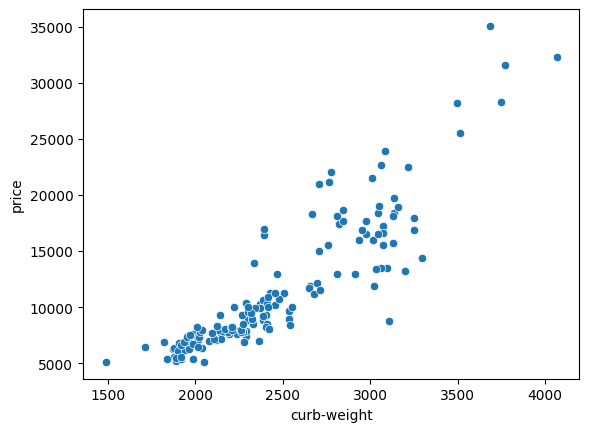

In [47]:
sns.scatterplot(data=df, x='curb-weight', y='price')
plt.show()

In [53]:
df[(df['price']<10000) & (df['width']<3500)]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
18,2,121,chevrolet,gas,std,two,hatchback,fwd,front,88.4,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151.0
19,1,98,chevrolet,gas,std,two,hatchback,fwd,front,94.5,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295.0
20,0,81,chevrolet,gas,std,four,sedan,fwd,front,94.5,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6575.0
21,1,118,dodge,gas,std,two,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572.0
22,1,118,dodge,gas,std,two,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,2,94,volkswagen,gas,std,four,sedan,fwd,front,97.3,...,109,mpfi,3.19,3.40,9.00,85,5250,27,34,8195.0
186,2,94,volkswagen,gas,std,four,sedan,fwd,front,97.3,...,109,mpfi,3.19,3.40,9.00,85,5250,27,34,8495.0
187,2,94,volkswagen,diesel,turbo,four,sedan,fwd,front,97.3,...,97,idi,3.01,3.40,23.00,68,4500,37,42,9495.0
188,2,94,volkswagen,gas,std,four,sedan,fwd,front,97.3,...,109,mpfi,3.19,3.40,10.00,100,5500,26,32,9995.0


In [60]:
df.reset_index(inplace=True)

In [61]:
df

,make,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,audi,2,164,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
1,audi,2,164,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
2,audi,1,158,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.0
3,audi,1,158,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.0
4,bmw,2,192,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,volvo,-1,95,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
155,volvo,-1,95,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
156,volvo,-1,95,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
157,volvo,-1,95,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [70]:
t10_cheveux = df.groupby('make')['horsepower'].sum().sort_values(ascending=False).head(10)

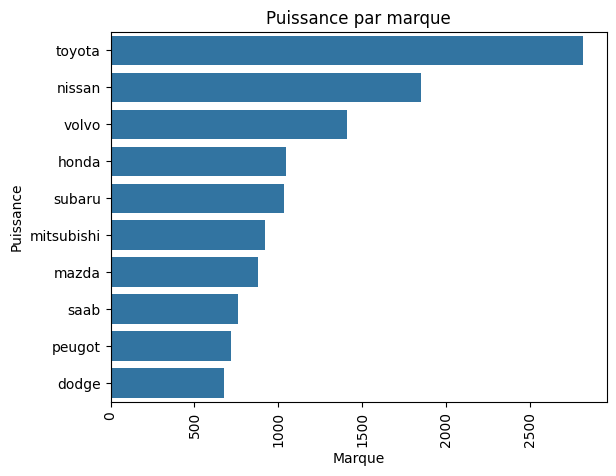

In [71]:
sns.barplot(y=t10_cheveux.index, x=t10_cheveux)
plt.xlabel('Marque')
plt.ylabel('Puissance')
plt.title('Puissance par marque')
plt.xticks(rotation=90)
plt.show()

In [72]:
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1

In [73]:
bas = Q1 - 1.5 * IQR
haut = Q3 + 1.5 * IQR

In [74]:
outliers = df[(df['horsepower'] < bas) | (df['horsepower'] > haut)]

In [80]:
bas,          haut

(np.float64(1.5), np.float64(181.5))

In [81]:
outliers

,make,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
75,nissan,3,194,gas,turbo,two,hatchback,rwd,front,91.3,...,181,mpfi,3.43,3.27,7.8,200,5200,17,23,19699.0


In [82]:
V1 = df['price'].quantile(0.25)
V3 = df['price'].quantile(0.75)
IQ = V3 - V1

In [83]:
bas = V1 - 1.5 * IQ
haut = V3 + 1.5 * IQ

In [84]:
erreur = df[(df['price'] < bas) | (df['price'] > haut)]

In [85]:
bas,             haut

(np.float64(-3649.25), np.float64(25740.75))

In [86]:
erreur

,make,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
32,jaguar,0,145,gas,std,four,sedan,rwd,front,113.0,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,32250.0
45,mercedes-benz,-1,93,diesel,turbo,four,wagon,rwd,front,110.0,...,183,idi,3.58,3.64,21.5,123,4350,22,25,28248.0
46,mercedes-benz,0,93,diesel,turbo,two,hardtop,rwd,front,106.7,...,183,idi,3.58,3.64,21.5,123,4350,22,25,28176.0
47,mercedes-benz,-1,93,diesel,turbo,four,sedan,rwd,front,115.6,...,183,idi,3.58,3.64,21.5,123,4350,22,25,31600.0
48,mercedes-benz,3,142,gas,std,two,convertible,rwd,front,96.6,...,234,mpfi,3.46,3.10,8.3,155,4750,16,18,35056.0


In [92]:
non_num = df.select_dtypes(exclude='number')
numeric = df.select_dtypes(include='number')

In [93]:
dumies = pd.get_dummies(non_num, drop_first=True)

In [96]:
df_final = pd.concat([dumies, numeric], axis=1)

In [97]:
df_final

,make_bmw,make_chevrolet,make_dodge,make_honda,make_jaguar,make_mazda,make_mercedes-benz,make_mitsubishi,make_nissan,make_peugot,...,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,False,False,False,False,False,False,False,False,False,...,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
1,False,False,False,False,False,False,False,False,False,False,...,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0
2,False,False,False,False,False,False,False,False,False,False,...,2844,136,3.19,3.40,8.5,110,5500,19,25,17710.0
3,False,False,False,False,False,False,False,False,False,False,...,3086,131,3.13,3.40,8.3,140,5500,17,20,23875.0
4,True,False,False,False,False,False,False,False,False,False,...,2395,108,3.50,2.80,8.8,101,5800,23,29,16430.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,False,False,False,False,False,False,False,False,False,False,...,2952,141,3.78,3.15,9.5,114,5400,23,28,16845.0
155,False,False,False,False,False,False,False,False,False,False,...,3049,141,3.78,3.15,8.7,160,5300,19,25,19045.0
156,False,False,False,False,False,False,False,False,False,False,...,3012,173,3.58,2.87,8.8,134,5500,18,23,21485.0
157,False,False,False,False,False,False,False,False,False,False,...,3217,145,3.01,3.40,23.0,106,4800,26,27,22470.0


In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [98]:
X = df_final.drop('price', axis=1)
y =df_final['price']

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [100]:
scale = StandardScaler()

In [101]:
scale_X_train = scale.fit_transform(X_train)
scale_X_test = scale.transform(X_test)

In [106]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [111]:
eval = []

In [139]:
model_elast = ElasticNet(random_state=42)

In [140]:
param_grid = {'alpha':[0.1, 1, 5, 10, 50, 100],
              'l1_ratio': [0.1, 0.5, 1],
              'max_iter': [1000, 5000, 10000]}

In [141]:
grid_elastic = GridSearchCV(model_elast, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [142]:
grid_elastic.fit(scale_X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 1],
                         'max_iter': [1000, 5000, 10000]},
             scoring='neg_mean_squared_error')

In [143]:
grid_elastic.best_params_

{'alpha': 5, 'l1_ratio': 1, 'max_iter': 1000}

In [144]:
y_pred = grid_elastic.predict(scale_X_test)

In [145]:
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred))

In [146]:
eval.append(rmse_elastic)

In [147]:
model_lineaire = LinearRegression()

In [148]:
model_lineaire.fit(scale_X_train, y_train)

LinearRegression()

In [149]:
y_pred = model_lineaire.predict(scale_X_test)

In [150]:
rmse_lineaire = np.sqrt(mean_squared_error(y_test, y_pred))

In [151]:
eval.append(rmse_lineaire)

In [152]:
from sklearn.svm import SVR

In [154]:
model_svr = SVR()

In [157]:
param_grid = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'degree': [2, 3, 4],
              'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 2, 3, 4, 'scale', 'auto']}

In [158]:
grid_svr = GridSearchCV(model_svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [159]:
grid_svr.fit(scale_X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000], 'degree': [2, 3, 4],
                         'gamma': [1, 2, 3, 4, 'scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='neg_mean_squared_error')

In [160]:
grid_svr.best_params_

{'C': 1000, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}

In [162]:
y_pred = grid_svr.predict(scale_X_test)

In [163]:
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred))

In [164]:
eval.append(rmse_svr)

In [166]:
from sklearn.neighbors import KNeighborsRegressor

In [167]:
model_knn = KNeighborsRegressor()

In [171]:
param_grid = {'n_neighbors': list(range(1, 11)),
              'weights': ['uniform', 'distance'],
              'p': [1, 2]}

In [172]:
grid_knn = GridSearchCV(model_knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [173]:
grid_knn.fit(scale_X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error')

In [178]:
grid_knn.best_params_

{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}

In [174]:
y_pred = grid_knn.predict(scale_X_test)

In [175]:
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred))

In [176]:
eval.append(rmse_knn)

In [177]:
from sklearn.tree import DecisionTreeRegressor

In [179]:
model_tree = DecisionTreeRegressor(random_state=42)

In [180]:
param_grid = {'max_depth': list(range(1, 11)),
              'min_samples_split': list(range(2, 11)),
              'min_samples_leaf': list(range(1, 11))}

In [181]:
grid_tree = GridSearchCV(model_tree, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [182]:
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='neg_mean_squared_error')

In [183]:
grid_tree.best_params_

{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 3}

In [185]:
y_pred = grid_tree.predict(X_test)

In [186]:
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred))

In [187]:
eval.append(rmse_tree)

In [188]:
from sklearn.ensemble import RandomForestRegressor

In [189]:
model_random = RandomForestRegressor(random_state=42)

In [191]:
param_grid = {'n_estimators': list(range(1, 11)),
              'max_depth': list(range(1, 11)),
              'min_samples_split': list(range(1, 11)),
              'min_samples_leaf': list(range(1, 11))}

In [192]:
grid_random = GridSearchCV(model_random, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [193]:
grid_random.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5000 fits failed out of a total of 50000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5000 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='neg_mean_squared_error')

In [194]:
grid_random.best_params_

{'max_depth': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 4}

In [195]:
y_pred = grid_random.predict(X_test)

In [196]:
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred))

In [197]:
eval.append(rmse_random)